# Amélioration de l’approche de classification

## Contexte et objectif

Cette étape prolonge le premier benchmark de classification réalisé sur les données d’attrition de TechNova Partners.

Les données préparées pour la modélisation sont déjà disponibles, ainsi qu’une première comparaison entre plusieurs modèles de référence. L’objectif de ce notebook est d’améliorer la qualité de la détection des employés susceptibles de quitter l’entreprise.

L’amélioration repose sur plusieurs leviers :
- l’enrichissement des variables par du feature engineering ;
- une séparation stratifiée des données ;
- l’utilisation d’un modèle non linéaire pondéré ;
- une validation croisée stratifiée ;
- l’ajustement du seuil de décision en fonction du compromis précision / rappel.

L’enjeu métier est de mieux repérer les départs potentiels, dans un contexte où la classe positive reste minoritaire.

## 1. Imports et configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder

pd.set_option ("display.max_columns", 200)
sns.set_theme (style="whitegrid")

## 2. Chargement des données préparées

Les données nettoyées et consolidées à l’étape précédente sont rechargées à partir du dossier `data/processed`.

La variable cible est ensuite standardisée puis encodée sous forme binaire afin de faciliter l’entraînement et l’évaluation des modèles.

In [2]:
PROJECT_ROOT = Path.cwd ( ).resolve ( ).parent if Path.cwd ( ).name == "notebooks" else Path.cwd ( ).resolve ( )
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

df_central = pd.read_csv (DATA_PROCESSED / "df_central.csv")

df_central["a_quitte_l_entreprise"] = (
    df_central["a_quitte_l_entreprise"]
    .astype (str)
    .str.strip ( )
    .str.capitalize ( )
)

df_central["attrition_bin"] = df_central["a_quitte_l_entreprise"].apply (
    lambda x: 1 if x == "Oui" else 0
)

print (df_central.shape)
display (df_central.head ( ))

(1470, 35)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,attrition_bin
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,E_1,3,Oui,11 %,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5,1
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,E_2,4,Non,23 %,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7,0
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,E_4,3,Oui,15 %,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0,1
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,E_5,3,Oui,11 %,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0,0
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,E_7,3,Non,12 %,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2,0


## 3. Fonctions utilitaires de préparation

Les fonctions ci-dessous permettent de structurer la préparation des données de manière plus lisible et réutilisable.

Elles prennent en charge :
- l’identification des variables numériques et catégorielles ;
- la construction de la cible ;
- la création de la matrice de features ;
- l’encodage des variables catégorielles ;
- la suppression des variables trop fortement corrélées.

In [3]:
def split_features_by_type(df: pd.DataFrame):
    num_cols = df.select_dtypes (include=["number"]).columns.tolist ( )
    cat_cols = df.select_dtypes (include=["object", "string", "category"]).columns.tolist ( )
    return num_cols, cat_cols


def build_target(df: pd.DataFrame, target_col: str = "attrition_bin") -> pd.Series:
    return df[target_col].copy ( )


def build_feature_matrix(
        df: pd.DataFrame,
        cols_to_drop: list[str] | None = None
) -> pd.DataFrame:
    if cols_to_drop is None:
        cols_to_drop = [
            "a_quitte_l_entreprise",
            "attrition_bin",
            "id_employee",
            "code_sondage",
            "eval_number",
        ]
    return df.drop (columns=[col for col in cols_to_drop if col in df.columns]).copy ( )


def fit_encoder_on_train(df: pd.DataFrame):
    df = df.copy ( )
    num_cols, cat_cols = split_features_by_type (df)

    if not cat_cols:
        return None, df

    encoder = OneHotEncoder (
        drop="first",
        handle_unknown="ignore",
        sparse_output=False
    )

    encoded_array = encoder.fit_transform (df[cat_cols])

    encoded_df = pd.DataFrame (
        encoded_array,
        columns=encoder.get_feature_names_out (cat_cols),
        index=df.index
    )

    df_encoded = pd.concat ([df[num_cols], encoded_df], axis=1)
    return encoder, df_encoded


def transform_with_encoder(df: pd.DataFrame, encoder) -> pd.DataFrame:
    df = df.copy ( )
    num_cols, cat_cols = split_features_by_type (df)

    if encoder is None or not cat_cols:
        return df

    encoded_array = encoder.transform (df[cat_cols])

    encoded_df = pd.DataFrame (
        encoded_array,
        columns=encoder.get_feature_names_out (cat_cols),
        index=df.index
    )

    return pd.concat ([df[num_cols], encoded_df], axis=1)


def drop_highly_correlated_features(df: pd.DataFrame, threshold: float = 0.8):
    corr_matrix = df.corr (numeric_only=True).abs ( )
    upper = corr_matrix.where (np.triu (np.ones (corr_matrix.shape), k=1).astype (bool))
    to_drop = [column for column in upper.columns if any (upper[column] > threshold)]
    return df.drop (columns=to_drop), to_drop

## 4. Feature engineering

Quelques variables dérivées sont construites afin d’enrichir la représentation initiale des employés.

L’objectif est de faire émerger des signaux potentiellement utiles à la classification, par exemple en combinant :
- le revenu et l’expérience ;
- l’ancienneté relative ;
- la charge liée à la distance domicile-travail ;
- un score synthétique de satisfaction.

In [4]:
df_fe = df_central.copy ( )

df_fe["revenu_par_annee_experience"] = (
        df_fe["revenu_mensuel"] / (df_fe["annee_experience_totale"] + 1)
)

df_fe["part_anciennete_entreprise"] = (
        df_fe["annees_dans_l_entreprise"] / (df_fe["annee_experience_totale"] + 1)
)

df_fe["part_anciennete_poste"] = (
        df_fe["annees_dans_le_poste_actuel"] / (df_fe["annees_dans_l_entreprise"] + 1)
)

df_fe["charge_distance"] = (
        df_fe["distance_domicile_travail"] * df_fe["nombre_heures_travailless"]
)

satisfaction_cols = [
    "satisfaction_employee_environnement",
    "satisfaction_employee_nature_travail",
    "satisfaction_employee_equipe",
    "satisfaction_employee_equilibre_pro_perso",
]

df_fe["score_satisfaction_moyen"] = df_fe[satisfaction_cols].mean (axis=1)

print (df_fe.shape)
display (df_fe.head ( ))

(1470, 40)


,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel,attrition_bin,revenu_par_annee_experience,part_anciennete_entreprise,part_anciennete_poste,charge_distance,score_satisfaction_moyen
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4,2,3,2,4,1,1,E_1,3,Oui,11 %,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5,1,665.888889,0.666667,0.571429,80,2.00
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7,3,2,2,2,4,3,E_2,4,Non,23 %,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7,0,466.363636,0.909091,0.636364,640,3.00
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0,4,2,1,3,2,3,E_4,3,Oui,15 %,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0,1,261.250000,0.000000,0.000000,160,3.00
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7,4,3,1,3,3,3,E_5,3,Oui,11 %,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0,0,323.222222,0.888889,0.777778,240,3.25
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2,1,3,1,2,4,3,E_7,3,Non,12 %,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2,0,495.428571,0.285714,0.666667,160,2.50


## 5. Construction de la cible et séparation train / test

La variable cible `attrition_bin` est isolée, puis les variables explicatives sont regroupées dans une matrice de features.

Les données sont ensuite séparées en jeu d’apprentissage et jeu de test avec une stratification sur la cible, afin de conserver une proportion comparable de départs dans les deux ensembles.

In [5]:
y = build_target (df_fe)
X_raw = build_feature_matrix (df_fe)

X_train_raw, X_test_raw, y_train, y_test = train_test_split (
    X_raw,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print ("X_train_raw :", X_train_raw.shape)
print ("X_test_raw  :", X_test_raw.shape)
print ("y_train     :", y_train.shape)
print ("y_test      :", y_test.shape)

print ("\nRépartition y_train :")
print (y_train.value_counts (normalize=True))

print ("\nRépartition y_test :")
print (y_test.value_counts (normalize=True))

X_train_raw : (1176, 35)
X_test_raw  : (294, 35)
y_train     : (1176,)
y_test      : (294,)

Répartition y_train :
attrition_bin
0    0.838435
1    0.161565
Name: proportion, dtype: float64

Répartition y_test :
attrition_bin
0    0.840136
1    0.159864
Name: proportion, dtype: float64


## 6. Encodage des variables et préparation finale

Les variables catégorielles sont encodées à partir du seul jeu d’apprentissage afin d’éviter toute fuite d’information.

Les variables trop corrélées sont ensuite retirées, puis les jeux train et test sont réalignés pour garantir la même structure finale.

In [6]:
encoder, X_train_prepared = fit_encoder_on_train (X_train_raw)
X_test_prepared = transform_with_encoder (X_test_raw, encoder)

X_train, dropped_corr_features = drop_highly_correlated_features (
    X_train_prepared,
    threshold=0.8
)

X_test = X_test_prepared.drop (columns=dropped_corr_features, errors="ignore")

X_train, X_test = X_train.align (
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print ("Shape final de X_train :", X_train.shape)
print ("Shape final de X_test  :", X_test.shape)
print ("NaN dans X_train :", X_train.isna ( ).sum ( ).sum ( ))
print ("NaN dans X_test  :", X_test.isna ( ).sum ( ).sum ( ))
print ("Variables supprimées :", dropped_corr_features)

Shape final de X_train : (1176, 58)
Shape final de X_test  : (294, 58)
NaN dans X_train : 0
NaN dans X_test  : 0
Variables supprimées : ['niveau_hierarchique_poste', 'charge_distance', 'poste_Ressources Humaines']


## 7. Définition du modèle

Le modèle retenu est une Random Forest avec pondération des classes (`class_weight="balanced"`).

Ce choix permet de mieux tenir compte du déséquilibre de la variable cible tout en conservant un modèle non linéaire capable de capturer des interactions plus complexes entre les variables.

In [7]:
rf_model = RandomForestClassifier (
    n_estimators=400,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

## 8. Recherche d’un seuil de décision sur un jeu de validation

Avant l’évaluation finale, un seuil de décision est recherché sur un sous-ensemble de validation extrait du jeu d’apprentissage.

Cette étape permet d’ajuster le compromis entre précision et rappel sans utiliser le jeu de test pour le réglage.

In [8]:
X_subtrain, X_valid, y_subtrain, y_valid = train_test_split (
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

rf_model.fit (X_subtrain, y_subtrain)

y_scores_valid = rf_model.predict_proba (X_valid)[:, 1]

precision, recall, thresholds = precision_recall_curve (y_valid, y_scores_valid)
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)

threshold_df = pd.DataFrame ({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
    "f1": f1_scores,
})

best_threshold_row = threshold_df.sort_values ("f1", ascending=False).iloc[0]
best_threshold = float (best_threshold_row["threshold"])
display (best_threshold_row)

threshold    0.459422
precision    0.513514
recall       0.500000
f1           0.506667
Name: 199, dtype: float64

## 9. Validation croisée stratifiée

Une validation croisée stratifiée est réalisée sur le jeu d’apprentissage afin d’obtenir une estimation plus robuste de la performance du modèle.

Cette étape permet d’évaluer la stabilité des métriques et de détecter un éventuel surapprentissage.

In [9]:
def evaluate_cv_model(model, X, y, n_splits=5):
    skf = StratifiedKFold (n_splits=n_splits, shuffle=True, random_state=42)

    fold_metrics = []

    for fold_idx, (train_idx, valid_idx) in enumerate (skf.split (X, y), start=1):
        X_fold_train = X.iloc[train_idx]
        X_fold_valid = X.iloc[valid_idx]
        y_fold_train = y.iloc[train_idx]
        y_fold_valid = y.iloc[valid_idx]

        model.fit (X_fold_train, y_fold_train)

        y_pred_train = model.predict (X_fold_train)
        y_pred_valid = model.predict (X_fold_valid)

        fold_metrics.append ({
            "fold": fold_idx,
            "train_accuracy": accuracy_score (y_fold_train, y_pred_train),
            "train_precision": precision_score (y_fold_train, y_pred_train, zero_division=0),
            "train_recall": recall_score (y_fold_train, y_pred_train, zero_division=0),
            "train_f1": f1_score (y_fold_train, y_pred_train, zero_division=0),
            "valid_accuracy": accuracy_score (y_fold_valid, y_pred_valid),
            "valid_precision": precision_score (y_fold_valid, y_pred_valid, zero_division=0),
            "valid_recall": recall_score (y_fold_valid, y_pred_valid, zero_division=0),
            "valid_f1": f1_score (y_fold_valid, y_pred_valid, zero_division=0),
        })

    return pd.DataFrame (fold_metrics)

In [10]:
cv_results = evaluate_cv_model (rf_model, X_train, y_train, n_splits=5)
display (cv_results)

,fold,train_accuracy,train_precision,train_recall,train_f1,valid_accuracy,valid_precision,valid_recall,valid_f1
0,1,0.959574,0.860759,0.894737,0.877419,0.885593,0.720000,0.473684,0.571429
1,2,0.950053,0.834395,0.861842,0.847896,0.829787,0.437500,0.184211,0.259259
2,3,0.956429,0.858065,0.875000,0.866450,0.872340,0.653846,0.447368,0.531250
3,4,0.944740,0.833333,0.822368,0.827815,0.868085,0.684211,0.342105,0.456140
4,5,0.953241,0.837500,0.881579,0.858974,0.846809,0.533333,0.421053,0.470588


In [11]:
cv_summary = cv_results.drop (columns="fold").agg (["mean", "std"]).T
display (cv_summary)

,mean,std
train_accuracy,0.952808,0.005740
train_precision,0.844810,0.013451
train_recall,0.867105,0.027679
train_f1,0.855711,0.018951
valid_accuracy,0.860523,0.022125
valid_precision,0.605778,0.117340
valid_recall,0.373684,0.116802
valid_f1,0.457733,0.120303


## 10. Évaluation finale du modèle avec le seuil par défaut

Le modèle est maintenant réentraîné sur l’ensemble du jeu d’apprentissage (`X_train`, `y_train`).

Cette étape permet d’obtenir une évaluation de référence avec le seuil standard de 0.5, avant d’appliquer le seuil optimisé retenu sur le jeu de validation.

In [12]:
rf_model.fit (X_train, y_train)

y_pred_train = rf_model.predict (X_train)
y_pred_test = rf_model.predict (X_test)

results_final = pd.DataFrame ([
    {
        "split": "train",
        "accuracy": accuracy_score (y_train, y_pred_train),
        "precision": precision_score (y_train, y_pred_train, zero_division=0),
        "recall": recall_score (y_train, y_pred_train, zero_division=0),
        "f1": f1_score (y_train, y_pred_train, zero_division=0),
    },
    {
        "split": "test",
        "accuracy": accuracy_score (y_test, y_pred_test),
        "precision": precision_score (y_test, y_pred_test, zero_division=0),
        "recall": recall_score (y_test, y_pred_test, zero_division=0),
        "f1": f1_score (y_test, y_pred_test, zero_division=0),
    },
]).round (3)

display (results_final)

,split,accuracy,precision,recall,f1
0,train,0.949,0.832,0.858,0.845
1,test,0.820,0.417,0.319,0.361


In [13]:
print ("TRAIN")
print (classification_report (y_train, y_pred_train, zero_division=0))

print ("TEST")
print (classification_report (y_test, y_pred_test, zero_division=0))

TRAIN
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       986
           1       0.83      0.86      0.84       190

    accuracy                           0.95      1176
   macro avg       0.90      0.91      0.91      1176
weighted avg       0.95      0.95      0.95      1176

TEST
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       247
           1       0.42      0.32      0.36        47

    accuracy                           0.82       294
   macro avg       0.65      0.62      0.63       294
weighted avg       0.80      0.82      0.81       294



## 11. Visualisation des performances du modèle

Les graphiques ci-dessous permettent de comparer les performances globales du modèle entre le jeu d’apprentissage et le jeu de test, puis de visualiser les matrices de confusion associées au seuil par défaut.

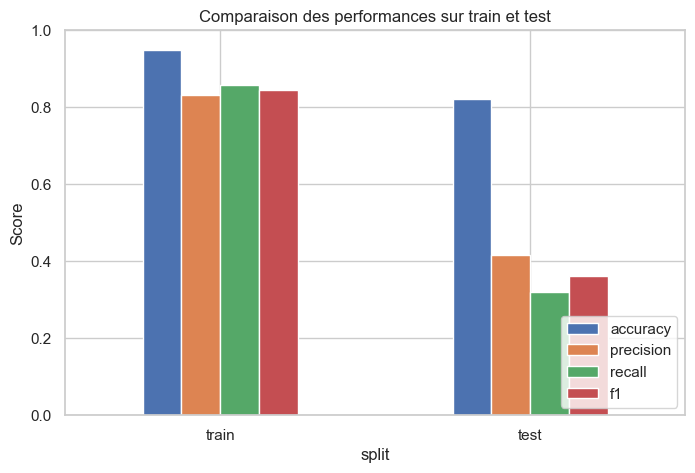

In [14]:
ax = results_final.set_index ("split").plot (kind="bar", figsize=(8, 5))
plt.title ("Comparaison des performances sur train et test")
plt.ylabel ("Score")
plt.xticks (rotation=0)
plt.ylim (0, 1)
plt.legend (loc="lower right")
plt.show ( )

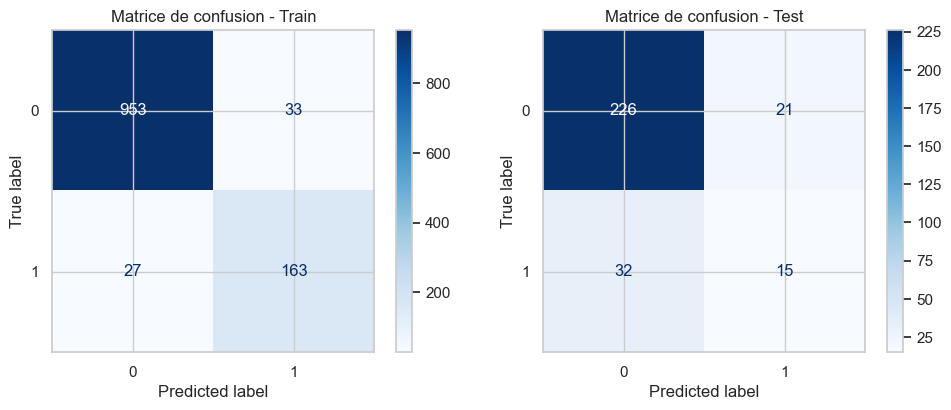

In [15]:
fig, axes = plt.subplots (1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions (y_train, y_pred_train, ax=axes[0], cmap="Blues")
axes[0].set_title ("Matrice de confusion - Train")

ConfusionMatrixDisplay.from_predictions (y_test, y_pred_test, ax=axes[1], cmap="Blues")
axes[1].set_title ("Matrice de confusion - Test")

plt.tight_layout ( )
plt.show ( )

## 12. Ajustement du seuil de décision

Le seuil retenu précédemment sur le jeu de validation est maintenant appliqué au jeu de test.

La courbe précision-rappel affichée ci-dessous sert uniquement à visualiser le comportement du modèle sur le test ; elle ne sert pas à choisir le seuil.

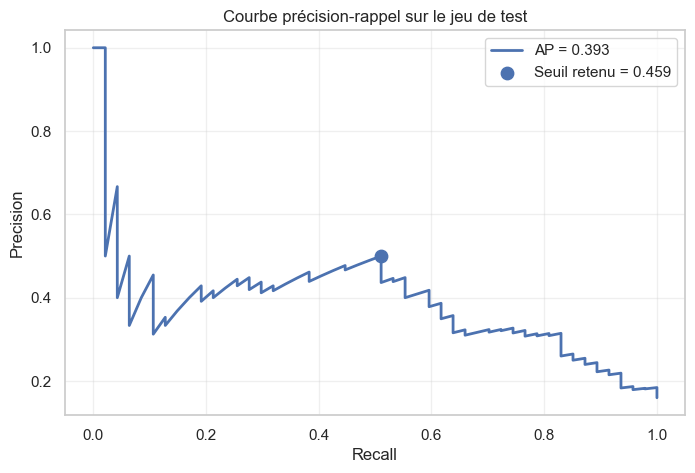

In [16]:
y_scores_test = rf_model.predict_proba (X_test)[:, 1]

precision_test, recall_test, thresholds_test = precision_recall_curve (y_test, y_scores_test)
ap_score = average_precision_score (y_test, y_scores_test)

idx_best = np.argmin (np.abs (thresholds_test - best_threshold))
best_precision = precision_test[idx_best]
best_recall = recall_test[idx_best]

plt.figure (figsize=(8, 5))
plt.plot (recall_test, precision_test, linewidth=2, label=f"AP = {ap_score:.3f}")
plt.scatter (
    best_recall,
    best_precision,
    s=80,
    label=f"Seuil retenu = {best_threshold:.3f}"
)
plt.xlabel ("Recall")
plt.ylabel ("Precision")
plt.title ("Courbe précision-rappel sur le jeu de test")
plt.legend ( )
plt.grid (alpha=0.3)
plt.show ( )

In [17]:
y_pred_test_default = (y_scores_test >= 0.5).astype (int)
y_pred_test_threshold = (y_scores_test >= best_threshold).astype (int)

comparison_threshold = pd.DataFrame ({
    "Seuil 0.5": [
        precision_score (y_test, y_pred_test_default, zero_division=0),
        recall_score (y_test, y_pred_test_default, zero_division=0),
        f1_score (y_test, y_pred_test_default, zero_division=0),
    ],
    f"Seuil optimisé ({best_threshold:.3f})": [
        precision_score (y_test, y_pred_test_threshold, zero_division=0),
        recall_score (y_test, y_pred_test_threshold, zero_division=0),
        f1_score (y_test, y_pred_test_threshold, zero_division=0),
    ]
}, index=["Precision", "Recall", "F1"]).round (3)

display (comparison_threshold)

,Seuil 0.5,Seuil optimisé (0.459)
Precision,0.417,0.489
Recall,0.319,0.489
F1,0.361,0.489


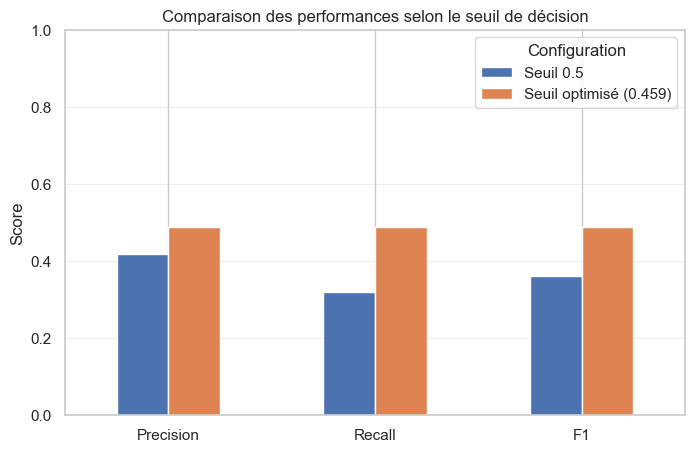

In [18]:
ax = comparison_threshold.plot (kind="bar", figsize=(8, 5))
plt.title ("Comparaison des performances selon le seuil de décision")
plt.ylabel ("Score")
plt.xticks (rotation=0)
plt.ylim (0, 1)
plt.grid (axis="y", alpha=0.3)
plt.legend (title="Configuration")
plt.show ( )

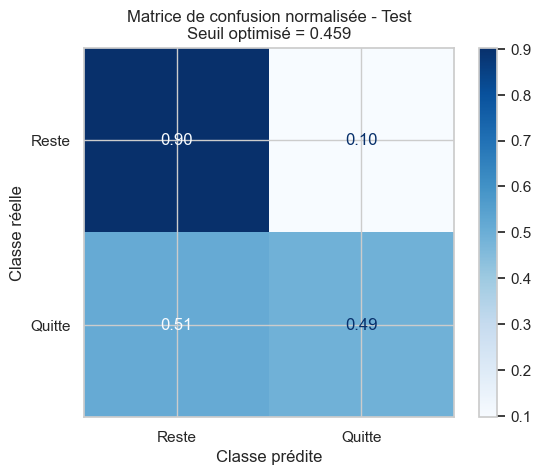

In [19]:
ConfusionMatrixDisplay.from_predictions (
    y_test,
    y_pred_test_threshold,
    display_labels=["Reste", "Quitte"],
    cmap="Blues",
    normalize="true",
    values_format=".2f"
)

plt.title (f"Matrice de confusion normalisée - Test\nSeuil optimisé = {best_threshold:.3f}")
plt.xlabel ("Classe prédite")
plt.ylabel ("Classe réelle")
plt.show ( )

In [20]:
print ("TEST AVEC SEUIL OPTIMISÉ SUR VALIDATION")
print (classification_report (y_test, y_pred_test_threshold, zero_division=0))

TEST AVEC SEUIL OPTIMISÉ SUR VALIDATION
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       247
           1       0.49      0.49      0.49        47

    accuracy                           0.84       294
   macro avg       0.70      0.70      0.70       294
weighted avg       0.84      0.84      0.84       294



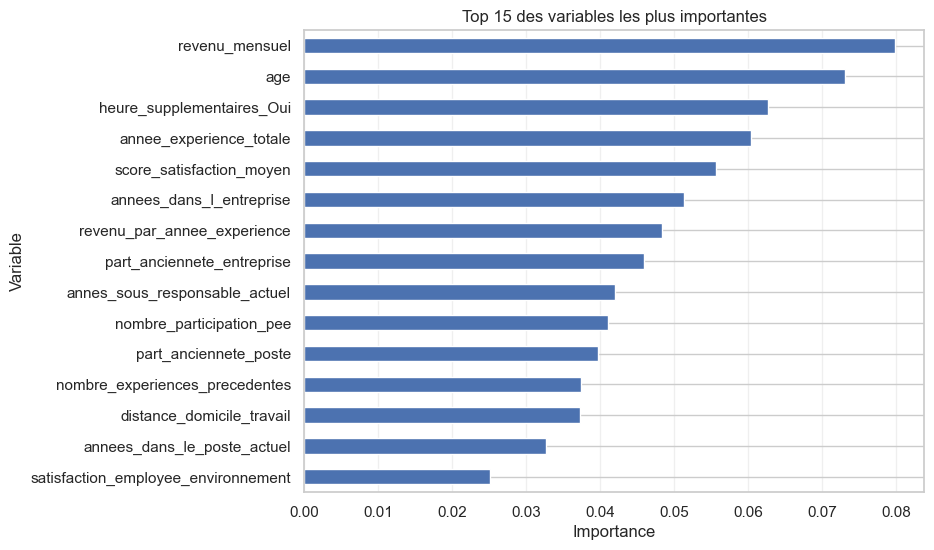

In [21]:
importances = pd.Series (
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values (ascending=False).head (15)

plt.figure (figsize=(8, 6))
importances.sort_values ( ).plot (kind="barh")
plt.title ("Top 15 des variables les plus importantes")
plt.xlabel ("Importance")
plt.ylabel ("Variable")
plt.grid (axis="x", alpha=0.3)
plt.show ( )

## 13. Interprétation des résultats

La validation croisée montre que le modèle présente encore un écart entre apprentissage et validation, ce qui suggère un surapprentissage modéré, mais plus maîtrisé que dans l’étape précédente.

Avec le seuil par défaut, le modèle obtient des performances globalement correctes, mais le rappel sur la classe positive reste limité. Autrement dit, une partie des départs réels n’est pas détectée.

L’ajustement du seuil permet d’obtenir un compromis plus cohérent avec le besoin métier. Dans une logique RH, il peut être préférable de détecter davantage de cas à risque, même au prix d’une baisse de précision.

Le modèle final ne doit donc pas être interprété uniquement à travers l’accuracy, mais aussi à travers sa capacité à repérer les employés susceptibles de quitter l’entreprise.

## Conclusion

Cette étape a permis d’améliorer l’approche de classification en intégrant plusieurs leviers méthodologiques :
- feature engineering ;
- séparation stratifiée ;
- modèle non linéaire pondéré ;
- validation croisée stratifiée ;
- ajustement du seuil de décision.

Le modèle obtenu reste perfectible, mais il fournit un compromis plus pertinent que les approches précédentes, en particulier dans un contexte de classes déséquilibrées.

Il constitue ainsi une base plus robuste pour la suite du projet, aussi bien pour l’évaluation prédictive que pour l’interprétation des facteurs associés à l’attrition.